[INFO] Data Preprocessing Successfully Complete!
Features Dataset Shape: (920, 5), Target Shape: (920,)

--- Logistic Regression Performance ---
Accuracy: 0.74

--- Decision Tree Performance ---
Accuracy: 0.77


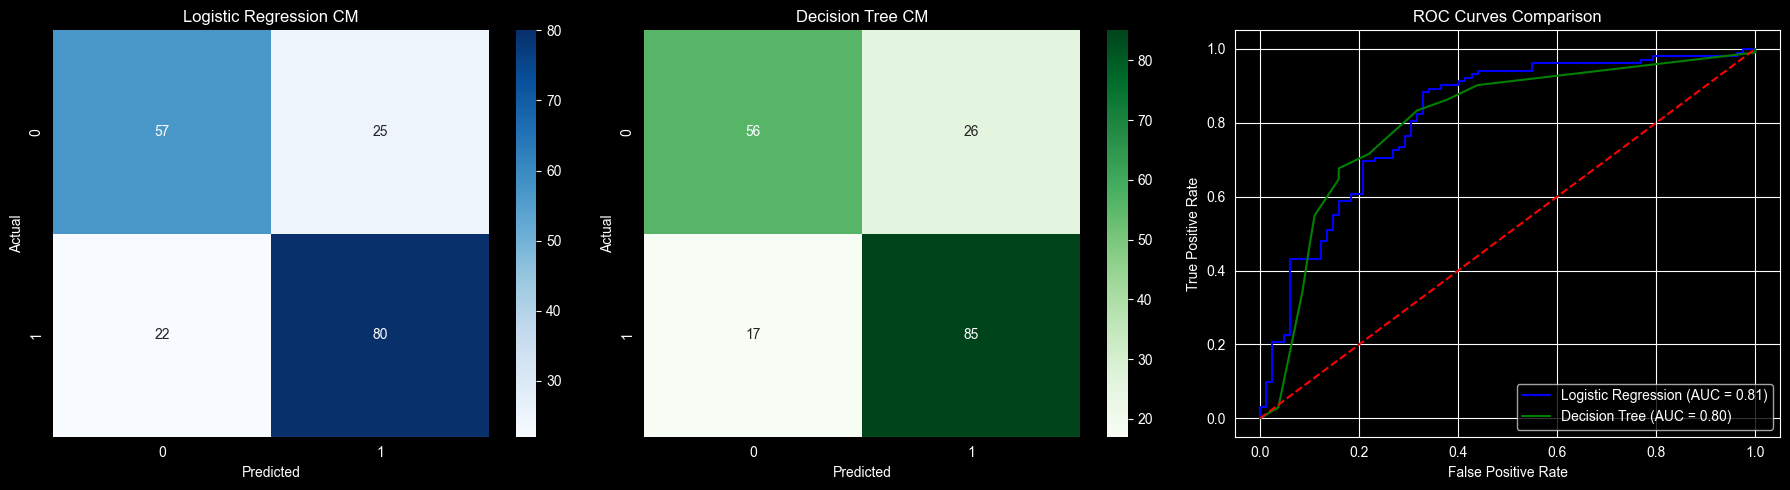

In [3]:
# ==========================================================
#  COMPLETED CODE
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc

# 1. Dataset load
data_path = "data/heart.csv"
df = pd.read_csv(data_path)

df = df.replace('?', np.nan)

# Target column (Binary Classification: 0 = No Risk, >0 = Risk)
if 'num' in df.columns:
    df['target'] = df['num'].apply(lambda x: 1 if x > 0 else 0)
elif 'target' in df.columns:
    df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)
else:
    df['target'] = df.iloc[:, -1].apply(lambda x: 1 if x > 0 else 0)

# [CRITICAL FIX]
safe_features = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']


X = df[safe_features].copy()
y = df['target']

for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors='coerce')
    X[col] = X[col].fillna(X[col].median())

print("[INFO] Data Preprocessing Successfully Complete!")
print(f"Features Dataset Shape: {X.shape}, Target Shape: {y.shape}\n")

# Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# ==========================================================
# MODELS TRAINING & EVALUATION
# ==========================================================

# 1. Logistic Regression Train
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)
lr_probs = lr_model.predict_proba(X_test)[:, 1]

print("--- Logistic Regression Performance ---")
print(f"Accuracy: {accuracy_score(y_test, lr_preds):.2f}")

# 2. Decision Tree Train
dt_model = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_model.fit(X_train, y_train)
dt_preds = dt_model.predict(X_test)
dt_probs = dt_model.predict_proba(X_test)[:, 1]

print("\n--- Decision Tree Performance ---")
print(f"Accuracy: {accuracy_score(y_test, dt_preds):.2f}")

# ==========================================================
# METRICS PLOTTING (Confusion Matrix & ROC Curves)
# ==========================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Logistic Regression Confusion Matrix
sns.heatmap(confusion_matrix(y_test, lr_preds), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Logistic Regression CM')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Decision Tree Confusion Matrix
sns.heatmap(confusion_matrix(y_test, dt_preds), annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Decision Tree CM')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

# ROC Curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_probs)
fpr_dt, tpr_dt, _ = roc_curve(y_test, dt_probs)

axes[2].plot(fpr_lr, tpr_lr, color='blue', label=f'Logistic Regression (AUC = {auc(fpr_lr, tpr_lr):.2f})')
axes[2].plot(fpr_dt, tpr_dt, color='green', label=f'Decision Tree (AUC = {auc(fpr_dt, tpr_dt):.2f})')
axes[2].plot([0, 1], [0, 1], color='red', linestyle='--')
axes[2].set_title('ROC Curves Comparison')
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].legend(loc='lower right')

plt.tight_layout()
plt.show()

--- Final Cleaned Features List ---
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal']

Final Accuracy with ALL features: 0.78



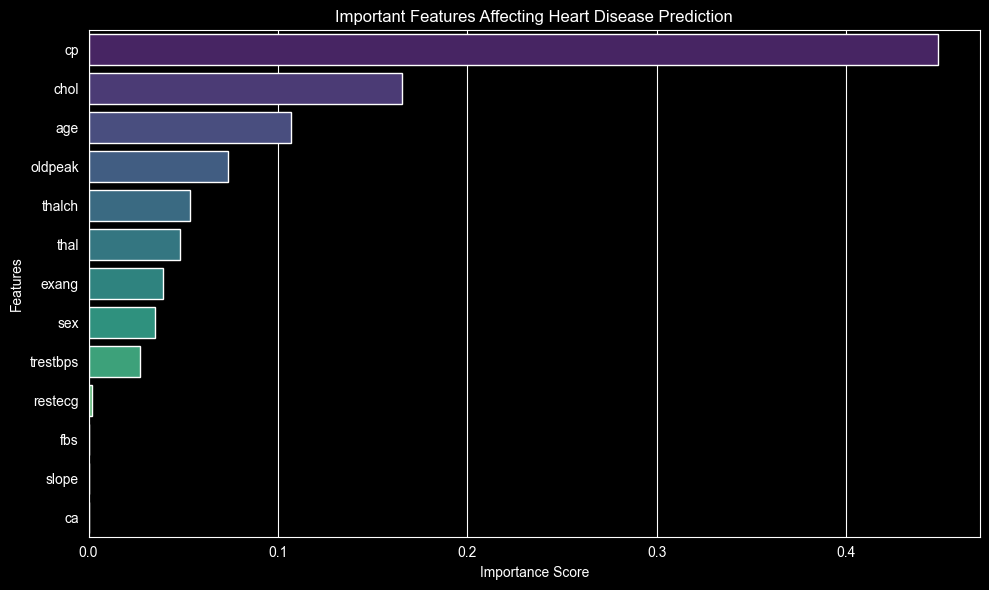

In [4]:
# ==========================================================
# ALL FEATURES INTEGRATION & FEATURE IMPORTANCE
# ==========================================================

df_final = pd.read_csv("data/heart.csv")
df_final = df_final.replace('?', np.nan)

# Target setting
if 'num' in df_final.columns:
    df_final['target'] = df_final['num'].apply(lambda x: 1 if x > 0 else 0)
    df_final.drop(columns=['num'], inplace=True, errors='ignore')

# Mapping categorical
mapping_dict = {
    'sex': {'Male': 1, 'Female': 0},
    'cp': {'typical angina': 1, 'atypical angina': 2, 'non-anginal': 3, 'asymptomatic': 4},
    'restecg': {'normal': 0, 'st-t abnormality': 1, 'lv hypertrophy': 2},
    'slope': {'upsloping': 1, 'flat': 2, 'downsloping': 3},
    'thal': {'normal': 3, 'fixed defect': 6, 'reversable defect': 7}
}

for col, mapping in mapping_dict.items():
    if col in df_final.columns:
        df_final[col] = df_final[col].map(mapping)

# Drop tracking columns
df_final.drop(columns=[col for col in ['id', 'dataset'] if col in df_final.columns], inplace=True, errors='ignore')

for col in df_final.columns:
    df_final[col] = pd.to_numeric(df_final[col], errors='coerce')
    df_final[col] = df_final[col].fillna(df_final[col].median())

# Train-Test Split with ALL features
X_all = df_final.drop(columns=['target'])
y_all = df_final['target']
X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(X_all, y_all, test_size=0.2, random_state=42, stratify=y_all)

# Retrain Decision Tree to calculate Feature Importance
dt_final = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_final.fit(X_train_a, y_train_a)

# Feature Importance Extract
importances = dt_final.feature_importances_
feature_imp_df = pd.DataFrame({'Feature': X_all.columns, 'Importance': importances})
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False)

print("--- Final Cleaned Features List ---")
print(list(X_all.columns))
print(f"\nFinal Accuracy with ALL features: {dt_final.score(X_test_a, y_test_a):.2f}\n")

# Feature Importance Graph Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis', hue='Feature', legend=False)
plt.title('Important Features Affecting Heart Disease Prediction')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()